In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install mediapipe opencv-python
import os
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
from google.colab.patches import cv2_imshow

Mounted at /content/drive


In [ ]:
# Mediapipe khởi tạo
mp_pose = mp.solutions.pose

# Hàm xử lý pose và lưu các landmarks
def extract_and_save_pose_to_csv(video_path, output_csv_path):
    with mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        # Đọc video
        cap = cv2.VideoCapture(video_path)
        frame_idx = 1
        results = []

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            # Chuyển đổi frame từ BGR sang RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Xử lý pose
            result = pose.process(frame_rgb)

            if result.pose_landmarks:
                # Nếu phát hiện landmarks, lưu tọa độ và visibility
                landmarks = []
                for landmark in result.pose_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])
                results.append([frame_idx] + landmarks)
            else:
                # Nếu không phát hiện khung xương, điền null (hoặc NaN)
                num_landmarks = len(mp_pose.PoseLandmark)
                empty_landmarks = [None] * (num_landmarks * 4)  # 4 giá trị mỗi landmark: x, y, z, visibility
                results.append([frame_idx] + empty_landmarks)

            frame_idx += 1

        cap.release()

        # Tạo DataFrame từ kết quả
        columns = ["Frame"] + [f"{name}_{coord}"
                               for name in mp_pose.PoseLandmark.__members__.keys()
                               for coord in ['x', 'y', 'z', 'visibility']]
        df = pd.DataFrame(results, columns=columns)

        # Lưu kết quả vào file CSV
        df.to_csv(output_csv_path, index=False)

# Duyệt qua từng thư mục và file trong data_path
def process_videos_to_csv(data_path, output_path):
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)

        if os.path.isdir(class_path):
            # Tạo thư mục tương ứng trong output_path
            output_class_path = os.path.join(output_path, class_name)
            os.makedirs(output_class_path, exist_ok=True)

            # Duyệt qua từng file .mp4
            for video_name in os.listdir(class_path):
                if video_name.endswith('.mp4'):
                    video_path = os.path.join(class_path, video_name)
                    output_csv_path = os.path.join(output_class_path, video_name.replace('.mp4', '.csv'))

                    print(f"Processing {video_path} -> {output_csv_path}")
                    extract_and_save_pose_to_csv(video_path, output_csv_path)

# Đường dẫn gốc
data_path = "/content/drive/MyDrive/Gym/data/Merge_data"  # Đường dẫn chứa các thư mục class và file .mp4 .mp4
output_path = "/content/drive/MyDrive/Gym/data/Merge_data_csv"  # Đường dẫn để lưu các file .csv

# # Gọi hàm xử lý
# process_videos_to_csv(data_path, output_path)


In [ ]:
import os
import cv2
import mediapipe as mp
import pandas as pd
import concurrent.futures

# Khởi tạo Mediapipe Pose
mp_pose = mp.solutions.pose

def extract_and_save_pose_to_csv(video_path, output_csv_path):
    with mp_pose.Pose(static_image_mode=False,
                      min_detection_confidence=0.5,
                      min_tracking_confidence=0.5) as pose:
        cap = cv2.VideoCapture(video_path)
        frame_idx = 1
        results = []

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = pose.process(frame_rgb)

            if result.pose_landmarks:
                landmarks = []
                for landmark in result.pose_landmarks.landmark:
                    # Lưu tọa độ pixel gốc
                    landmarks.extend([
                        int(landmark.x * frame.shape[1]),  # x in pixels
                        int(landmark.y * frame.shape[0]),  # y in pixels
                        landmark.z,  # z
                        landmark.visibility
                    ])
                results.append([frame_idx] + landmarks)
            else:
                num_landmarks = len(mp_pose.PoseLandmark)
                empty_landmarks = [None] * (num_landmarks * 4)
                results.append([frame_idx] + empty_landmarks)

            frame_idx += 1

        cap.release()

        columns = ["Frame"] + [f"{name}_{coord}"
                               for name in mp_pose.PoseLandmark.__members__.keys()
                               for coord in ['x', 'y', 'z', 'visibility']]
        df = pd.DataFrame(results, columns=columns)
        df.to_csv(output_csv_path, index=False)

def process_video(video_path, output_csv_path):
    print(f"Processing {video_path} -> {output_csv_path}")
    try:
        extract_and_save_pose_to_csv(video_path, output_csv_path)
    except Exception as e:
        print(f"Error processing {video_path}: {e}")

def process_videos_to_csv(data_path, output_path, max_workers=4):
    # Duyệt qua từng thư mục lớp
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        if os.path.isdir(class_path):
            output_class_path = os.path.join(output_path, class_name)
            os.makedirs(output_class_path, exist_ok=True)
            video_tasks = []
            # Lấy danh sách các video trong thư mục
            for video_name in os.listdir(class_path):
                if video_name.endswith('.mp4'):
                    video_path = os.path.join(class_path, video_name)
                    output_csv_path = os.path.join(output_class_path, video_name.replace('.mp4', '.csv'))
                    video_tasks.append((video_path, output_csv_path))

            # Xử lý song song các video trong thư mục này
            with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
                futures = [executor.submit(process_video, vp, op) for vp, op in video_tasks]
                for future in concurrent.futures.as_completed(futures):
                    future.result()

# Ví dụ gọi hàm xử lý cho tập test, train, val
data_paths = {
    "data": "/content/drive/MyDrive/Gym/data/Merge_data"
}

output_paths = {
    "data": "/content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize"
}

for key in data_paths:
    process_videos_to_csv(data_paths[key], output_paths[key], max_workers=16)


Processing /content/drive/MyDrive/Gym/data/Merge_data/barbell biceps curl/barbell biceps curl_14.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize/barbell biceps curl/barbell biceps curl_14.csv
Processing /content/drive/MyDrive/Gym/data/Merge_data/barbell biceps curl/barbell biceps curl_27.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize/barbell biceps curl/barbell biceps curl_27.csv
Processing /content/drive/MyDrive/Gym/data/Merge_data/barbell biceps curl/barbell biceps curl_32.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize/barbell biceps curl/barbell biceps curl_32.csv
Processing /content/drive/MyDrive/Gym/data/Merge_data/barbell biceps curl/barbell biceps curl_2.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize/barbell biceps curl/barbell biceps curl_2.csv
Processing /content/drive/MyDrive/Gym/data/Merge_data/barbell biceps curl/barbell biceps curl_12.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_

In [ ]:
import os
import cv2
import mediapipe as mp
import pandas as pd
import concurrent.futures

# Khởi tạo Mediapipe Pose
mp_pose = mp.solutions.pose

def extract_and_save_pose_to_csv(video_path, output_csv_path):
    with mp_pose.Pose(static_image_mode=False,
                      min_detection_confidence=0.5,
                      min_tracking_confidence=0.5) as pose:
        cap = cv2.VideoCapture(video_path)
        frame_idx = 1
        results = []

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = pose.process(frame_rgb)

            if result.pose_landmarks:
                landmarks = []
                for landmark in result.pose_landmarks.landmark:
                    # Lưu tọa độ pixel gốc
                    landmarks.extend([
                        int(landmark.x * frame.shape[1]),  # x in pixels
                        int(landmark.y * frame.shape[0]),  # y in pixels
                        landmark.z,  # z
                        landmark.visibility
                    ])
                results.append([frame_idx] + landmarks)
            else:
                num_landmarks = len(mp_pose.PoseLandmark)
                empty_landmarks = [None] * (num_landmarks * 4)
                results.append([frame_idx] + empty_landmarks)

            frame_idx += 1

        cap.release()

        columns = ["Frame"] + [f"{name}_{coord}"
                               for name in mp_pose.PoseLandmark.__members__.keys()
                               for coord in ['x', 'y', 'z', 'visibility']]
        df = pd.DataFrame(results, columns=columns)
        df.to_csv(output_csv_path, index=False)

def process_video(video_path, output_csv_path):
    print(f"Processing {video_path} -> {output_csv_path}")
    try:
        extract_and_save_pose_to_csv(video_path, output_csv_path)
    except Exception as e:
        print(f"Error processing {video_path}: {e}")

def process_videos_to_csv(data_path, output_path, max_workers=4):
    # Duyệt qua từng thư mục lớp
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        if os.path.isdir(class_path):
            output_class_path = os.path.join(output_path, class_name)
            os.makedirs(output_class_path, exist_ok=True)
            video_tasks = []
            # Lấy danh sách các video trong thư mục
            for video_name in os.listdir(class_path):
                if video_name.endswith('.mp4'):
                    video_path = os.path.join(class_path, video_name)
                    output_csv_path = os.path.join(output_class_path, video_name.replace('.mp4', '.csv'))
                    video_tasks.append((video_path, output_csv_path))

            # Xử lý song song các video trong thư mục này
            with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
                futures = [executor.submit(process_video, vp, op) for vp, op in video_tasks]
                for future in concurrent.futures.as_completed(futures):
                    future.result()

# Ví dụ gọi hàm xử lý cho tập test, train, val
data_paths = {
    "data": "/content/drive/MyDrive/Gym/data/Merge_data"
}

output_paths = {
    "data": "/content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize"
}

for key in data_paths:
    process_videos_to_csv(data_paths[key], output_paths[key], max_workers=32)


In [ ]:
import os
import cv2
import mediapipe as mp
import pandas as pd
import concurrent.futures

# Khởi tạo Mediapipe Pose
mp_pose = mp.solutions.pose

def extract_and_save_pose_to_csv(video_path, output_csv_path):
    with mp_pose.Pose(static_image_mode=False,
                      min_detection_confidence=0.5,
                      min_tracking_confidence=0.5) as pose:
        cap = cv2.VideoCapture(video_path)
        frame_idx = 1
        results = []

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = pose.process(frame_rgb)

            if result.pose_landmarks:
                landmarks = []
                for landmark in result.pose_landmarks.landmark:
                    # Lưu tọa độ pixel gốc
                    landmarks.extend([
                        int(landmark.x * frame.shape[1]),  # x in pixels
                        int(landmark.y * frame.shape[0]),  # y in pixels
                        landmark.z,                      # z
                        landmark.visibility
                    ])
                results.append([frame_idx] + landmarks)
            else:
                num_landmarks = len(mp_pose.PoseLandmark)
                empty_landmarks = [None] * (num_landmarks * 4)
                results.append([frame_idx] + empty_landmarks)

            frame_idx += 1

        cap.release()

        columns = ["Frame"] + [f"{name}_{coord}"
                               for name in mp_pose.PoseLandmark.__members__.keys()
                               for coord in ['x', 'y', 'z', 'visibility']]
        df = pd.DataFrame(results, columns=columns)
        df.to_csv(output_csv_path, index=False)

def process_video(video_path, output_csv_path):
    print(f"Processing {video_path} -> {output_csv_path}")
    try:
        extract_and_save_pose_to_csv(video_path, output_csv_path)
    except Exception as e:
        print(f"Error processing {video_path}: {e}")

def process_videos_in_folder(input_folder, output_folder, max_workers=4):
    os.makedirs(output_folder, exist_ok=True)
    video_tasks = []
    # Lấy danh sách các video trong folder hiện tại
    for video_name in os.listdir(input_folder):
        if video_name.endswith('.mp4'):
            video_path = os.path.join(input_folder, video_name)
            output_csv_path = os.path.join(output_folder, video_name.replace('.mp4', '.csv'))
            video_tasks.append((video_path, output_csv_path))

    # Xử lý song song các video trong folder
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_video, vp, op) for vp, op in video_tasks]
        for future in concurrent.futures.as_completed(futures):
            future.result()

# Danh sách các folder cần xử lý
input_folders = [
    # "/content/drive/MyDrive/Gym/data/Merge_data/leg raises",
    # "/content/drive/MyDrive/Gym/data/Merge_data/plank",
    # "/content/drive/MyDrive/Gym/data/Merge_data/pull Up",
    # "/content/drive/MyDrive/Gym/data/Merge_data/push-up",
    # "/content/drive/MyDrive/Gym/data/Merge_data/romanian deadlift",
    # "/content/drive/MyDrive/Gym/data/Merge_data/russian twist",
    # "/content/drive/MyDrive/Gym/data/Merge_data/shoulder press",
    # "/content/drive/MyDrive/Gym/data/Merge_data/squat",
    # "/content/drive/MyDrive/Gym/data/Merge_data/t bar row",
    # "/content/drive/MyDrive/Gym/data/Merge_data/tricep Pushdown",
    # "/content/drive/MyDrive/Gym/data/Merge_data/tricep dips",
    # "/content/drive/MyDrive/Gym/data/Merge_data/leg extension",
    "/content/drive/MyDrive/Gym/data/New folder"
]

# Folder đầu ra gốc
output_root = "/content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize"

# Xử lý từng folder trong danh sách
for folder in input_folders:
    folder_name = os.path.basename(folder)
    output_folder = os.path.join(output_root, folder_name)
    process_videos_in_folder(folder, output_folder, max_workers=32)


Processing /content/drive/MyDrive/Gym/data/New folder/Master the Assisted Dip Machine- Here_s Why You Need It!.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize/New folder/Master the Assisted Dip Machine- Here_s Why You Need It!.csv
Processing /content/drive/MyDrive/Gym/data/New folder/100 Tricep Dip Challenge.mp4 -> /content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize/New folder/100 Tricep Dip Challenge.csv


Check

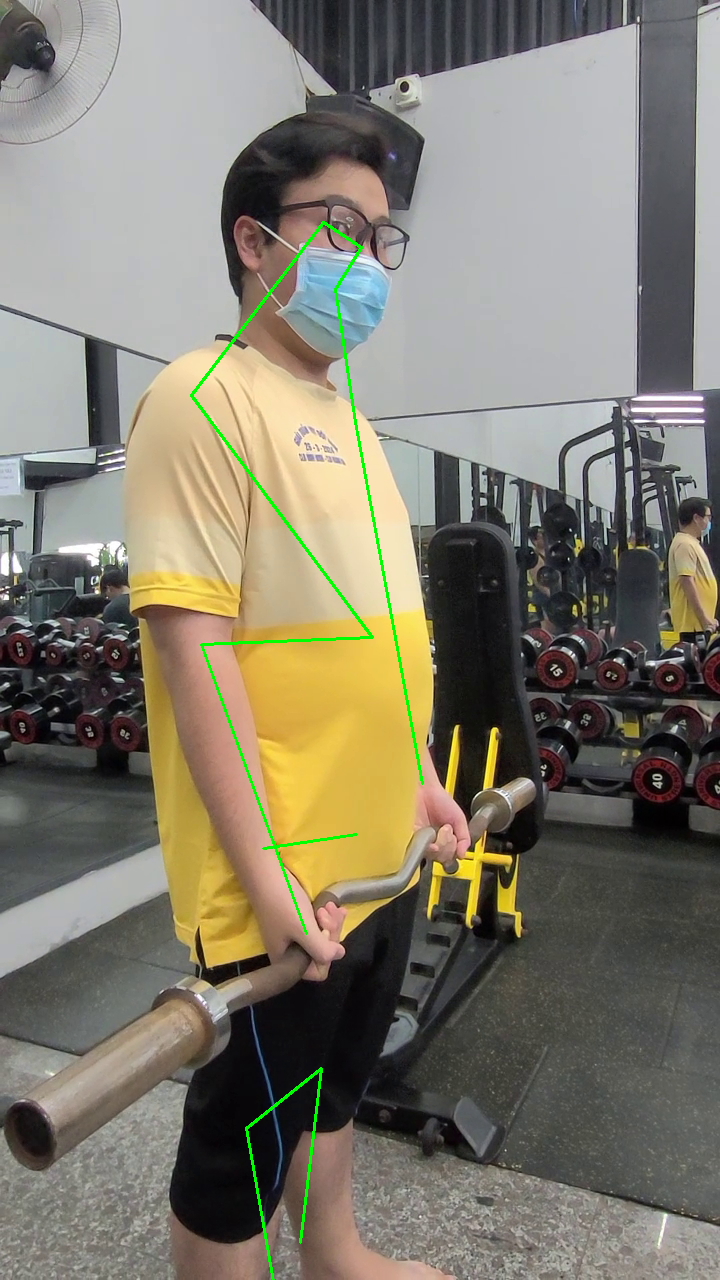

In [15]:
# Initialize Mediapipe Pose
mp_pose = mp.solutions.pose
pose_connections = mp_pose.POSE_CONNECTIONS

# Function to draw skeleton from landmark coordinates
def draw_skeleton(image, landmarks):
    for connection in pose_connections:
        start_idx = connection[0]
        end_idx = connection[1]
        if start_idx < len(landmarks) and end_idx < len(landmarks):
            start_landmark = landmarks[start_idx]
            end_landmark = landmarks[end_idx]

            cv2.line(image,
                     (int(start_landmark[0]), int(start_landmark[1])),
                     (int(end_landmark[0]), int(end_landmark[1])),
                     (0, 255, 0), 2)
    return image

# Function to read landmarks from CSV
def read_landmarks_from_csv(csv_file, frame_idx):
    try:
        # Read the CSV file
        df = pd.read_csv(csv_file)

        # Check if the "Frame" column exists
        if "Frame" not in df.columns:
            print("Lỗi: File CSV không có cột 'Frame'.")
            return []

        # Check if the frame exists
        if frame_idx not in df["Frame"].values:
            print(f"Không có landmarks nào tại frame {frame_idx}")
            return []

        # Extract the row corresponding to the frame index
        frame_data = df[df["Frame"] == frame_idx]

        # Extract landmarks (x, y) for all points
        landmarks = []
        for col in df.columns:
            if col.endswith("_x"):
                base_name = col[:-2]  # Remove "_x" to get the base name
                x = frame_data[f"{base_name}_x"].values[0]
                y = frame_data[f"{base_name}_y"].values[0]
                landmarks.append((x, y))
        return landmarks
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        return []

# Function to get a frame from video
def get_frame_from_video(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if ret:
        return frame
    else:
        print(f"Error: Unable to retrieve frame {frame_idx} from {video_path}")
        return None

# Main function to process
def check_pose_from_csv(video_path, csv_file, frame_idx):
    # Read the frame from video
    frame = get_frame_from_video(video_path, frame_idx)
    if frame is None:
        return

    # Read landmarks from the CSV file
    landmarks = read_landmarks_from_csv(csv_file, frame_idx)

    if not landmarks:
        print(f"Không có dữ liệu landmarks để vẽ tại frame {frame_idx}")
        return

    # Scale landmarks back to frame dimensions
    h, w, _ = frame.shape
    scaled_landmarks = [(int(l[0]), int(l[1])) for l in landmarks]

    # Draw the skeleton on the frame
    frame_with_skeleton = draw_skeleton(frame, scaled_landmarks)

    # Display the frame using cv2_imshow
    cv2_imshow(frame_with_skeleton)

# Paths
video_path = "/content/drive/MyDrive/Gym/data/Merge_data/barbell biceps curl/barbell biceps curl_2 - Copy.mp4"  # Replace with your video path
csv_file = "/content/drive/MyDrive/Gym/data/Merge_data_to_csv_unnormalize_split_03/test/barbell biceps curl/barbell biceps curl_2 - Copy.csv"  # Replace with your CSV file path
frame_idx = 20  # Example: Check the 9th frame (adjust based on your needs)

# Call the function
check_pose_from_csv(video_path, csv_file, frame_idx)
